<style>
h1, h1 *, 
h2, h2 *, 
h3, h3 *, 
h4, h4 *, 
h5, h5 *, 
h6, h6 * {
  font-family: "Times New Roman", Times, serif !important;

</style>

### **Credit Risk Modelling**

---

In [1]:
import sys
!{sys.executable} -m pip install streamlit

In [2]:
import sys
!{sys.executable} -m pip install joblib

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
pd.set_option('display.max_columns', None)

In [5]:
df = pd.read_csv('Credit Risk Modelling - Dataset.csv')
df.head()

,Unnamed: 0,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,0,67,male,2,own,NaN,little,1169,6,radio/TV,good
1,1,22,female,2,own,little,moderate,5951,48,radio/TV,bad
2,2,49,male,1,own,little,NaN,2096,12,education,good
3,3,45,male,2,free,little,little,7882,42,furniture/equipment,good
4,4,53,male,2,free,little,little,4870,24,car,bad


In [6]:
df['Age'].describe()

count    1000.000000
mean       35.546000
std        11.375469
min        19.000000
25%        27.000000
50%        33.000000
75%        42.000000
max        75.000000
Name: Age, dtype: float64

In [7]:
df.isna().sum()

Unnamed: 0            0
Age                   0
Sex                   0
Job                   0
Housing               0
Saving accounts     183
Checking account    394
Credit amount         0
Duration              0
Purpose               0
Risk                  0
dtype: int64

In [8]:
df['Risk'].value_counts()

Risk
good    700
bad     300
Name: count, dtype: int64

In [9]:
df.shape

(1000, 11)

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Unnamed: 0        1000 non-null   int64 
 1   Age               1000 non-null   int64 
 2   Sex               1000 non-null   object
 3   Job               1000 non-null   int64 
 4   Housing           1000 non-null   object
 5   Saving accounts   817 non-null    object
 6   Checking account  606 non-null    object
 7   Credit amount     1000 non-null   int64 
 8   Duration          1000 non-null   int64 
 9   Purpose           1000 non-null   object
 10  Risk              1000 non-null   object
dtypes: int64(5), object(6)
memory usage: 86.1+ KB


In [11]:
df.describe(include = 'all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Unnamed: 0,1000.0,NaN,NaN,NaN,499.5,288.819436,0.0,249.75,499.5,749.25,999.0
Age,1000.0,NaN,NaN,NaN,35.546,11.375469,19.0,27.0,33.0,42.0,75.0
Sex,1000,2,male,690,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Job,1000.0,NaN,NaN,NaN,1.904,0.653614,0.0,2.0,2.0,2.0,3.0
Housing,1000,3,own,713,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Saving accounts,817,4,little,603,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Checking account,606,3,little,274,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Credit amount,1000.0,NaN,NaN,NaN,3271.258,2822.736876,250.0,1365.5,2319.5,3972.25,18424.0
Duration,1000.0,NaN,NaN,NaN,20.903,12.058814,4.0,12.0,18.0,24.0,72.0
Purpose,1000,8,car,337,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [12]:
print(df['Job'].unique())

[2 1 3 0]


In [13]:
print(df.duplicated().sum())

0


In [14]:
df = df.dropna().reset_index(drop = True)

In [15]:
df.shape

(522, 11)

In [16]:
df.columns

Index(['Unnamed: 0', 'Age', 'Sex', 'Job', 'Housing', 'Saving accounts',
       'Checking account', 'Credit amount', 'Duration', 'Purpose', 'Risk'],
      dtype='object')

In [17]:
df.drop(columns = 'Unnamed: 0', inplace = True)

In [18]:
df.columns

Index(['Age', 'Sex', 'Job', 'Housing', 'Saving accounts', 'Checking account',
       'Credit amount', 'Duration', 'Purpose', 'Risk'],
      dtype='object')

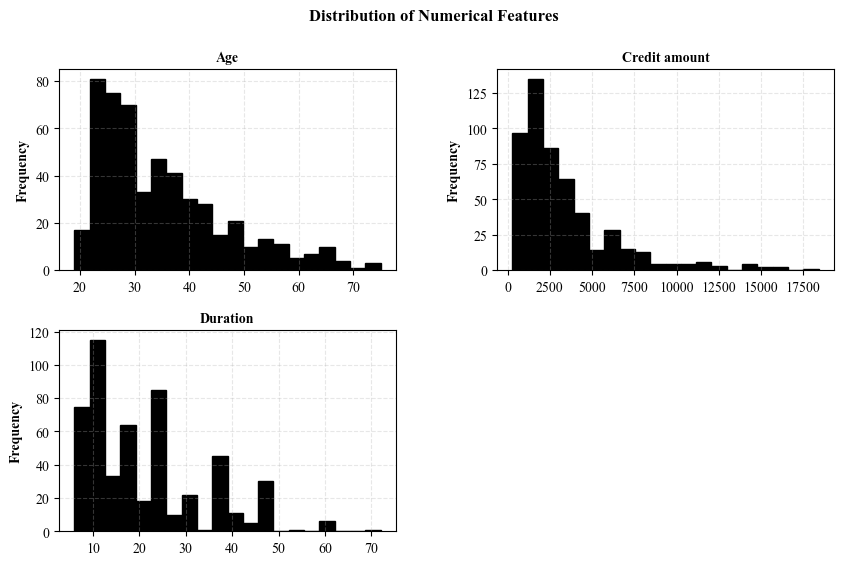

In [60]:
from matplotlib import rcParams
rcParams['font.family'] = 'Times New Roman'

numerical_cols = ['Age', 'Credit amount', 'Duration']
axes = df[numerical_cols].hist(bins = 20, figsize = (10, 6), color = 'black', edgecolor = 'black')
plt.suptitle('Distribution of Numerical Features', fontweight = 'bold', fontsize = 12)
for ax in axes.flatten():
    ax.set_xlabel(ax.get_xlabel(), fontweight = 'bold')
    ax.set_ylabel('Frequency', fontweight = 'bold')
    ax.set_title(ax.get_title(), fontweight = 'bold', fontsize = 10)
    ax.grid(True, linestyle = '--', alpha = 0.3)

plt.show()

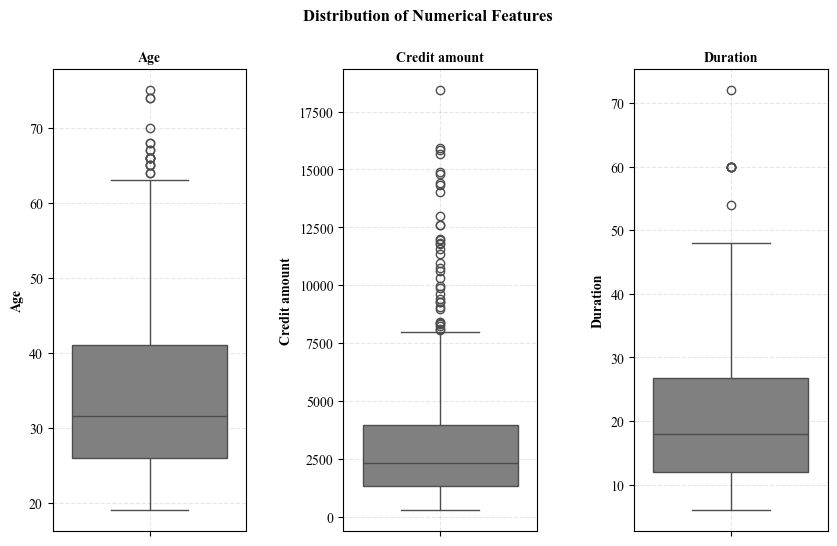

In [59]:
fig, axes = plt.subplots(1, 3, figsize = (10, 6))
fig.suptitle('Distribution of Numerical Features', fontweight = 'bold', fontsize = 12)
for ax, col in zip(axes, ['Age', 'Credit amount', 'Duration']):
    sns.boxplot(y = df[col], color = 'grey', ax = ax)
    ax.set_title(col, fontweight = 'bold', fontsize = 10)
    ax.set_xlabel('')
    ax.set_ylabel(col, fontweight = 'bold')
    ax.grid(True, linestyle = '--', alpha = 0.3)

plt.subplots_adjust(top = 0.88, wspace = 0.5)
plt.show()

In [29]:
df.query('Duration >= 60')

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
18,63,male,2,own,little,little,6836,60,business,bad
176,24,female,3,own,moderate,moderate,7408,60,car,bad
199,60,female,3,free,moderate,moderate,14782,60,vacation/others,bad
358,24,male,2,own,moderate,moderate,5595,72,radio/TV,bad
378,27,male,3,own,little,moderate,14027,60,car,bad
489,42,male,2,free,little,moderate,6288,60,education,bad
507,36,male,2,rent,little,little,7297,60,business,bad


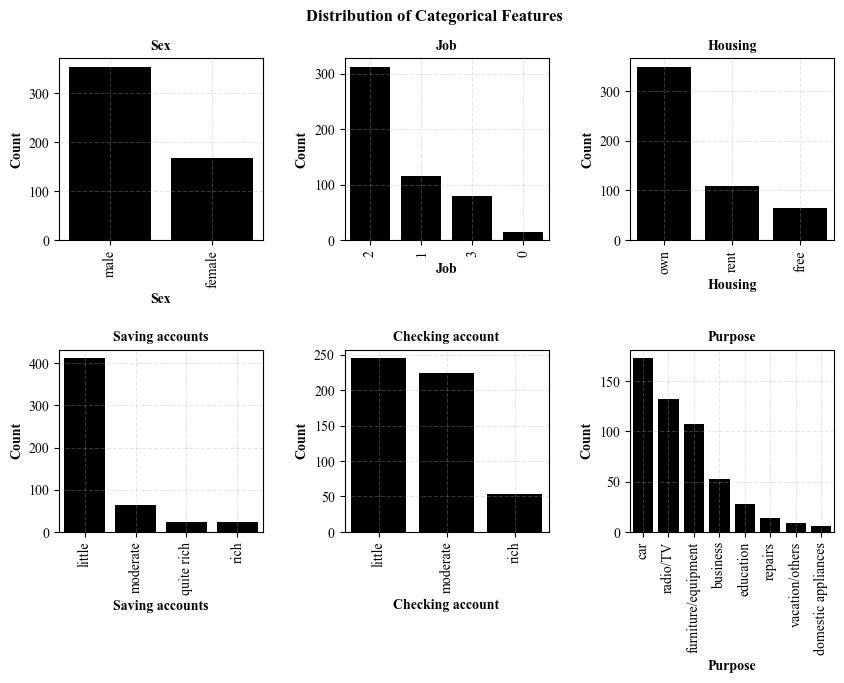

In [57]:
categorical_cols = ['Sex', 'Job', 'Housing', 'Saving accounts', 'Checking account', 'Purpose']

fig, axes = plt.subplots(2, 3, figsize = (10, 6))
fig.suptitle('Distribution of Categorical Features', fontweight = 'bold', fontsize = 12)
for ax, col in zip(axes.flatten(), categorical_cols):
    sns.countplot(data = df, x = col, order = df[col].value_counts().index, color = 'black', ax = ax)
    ax.set_title(col, fontweight = 'bold', fontsize = 10)
    ax.set_xlabel(col, fontweight = 'bold')
    ax.set_ylabel('Count', fontweight = 'bold')
    ax.tick_params(axis = 'x', rotation = 90)
    ax.grid(True, linestyle = '--', alpha = 0.3)

plt.subplots_adjust(top = 0.90, hspace = 0.6, wspace = 0.4)
plt.show()

In [38]:
corr = df[['Age', 'Job', 'Credit amount', 'Duration']].corr()
corr

,Age,Job,Credit amount,Duration
Age,1.000000,0.039771,0.082014,0.001549
Job,0.039771,1.000000,0.334721,0.200794
Credit amount,0.082014,0.334721,1.000000,0.613298
Duration,0.001549,0.200794,0.613298,1.000000


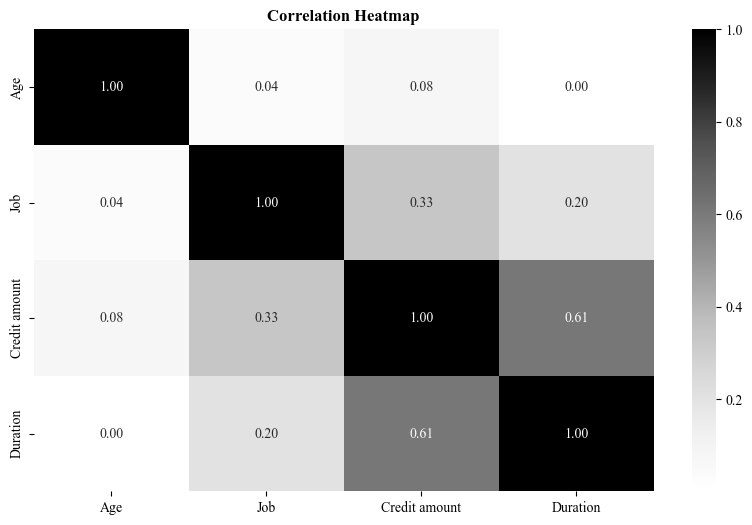

In [40]:
fig, ax = plt.subplots(figsize = (10, 6))
sns.heatmap(corr, annot = True, cmap = 'Greys', fmt = '.2f', ax = ax)
ax.set_title('Correlation Heatmap', fontweight = 'bold', fontsize = 12)
ax.grid(False)

plt.show()

In [41]:
df.groupby('Job')['Credit amount'].mean()

Job
0    1767.857143
1    2250.715517
2    3129.130990
3    5648.784810
Name: Credit amount, dtype: float64

In [42]:
df.groupby('Sex')['Credit amount'].mean()

Sex
female    2937.202381
male      3440.833333
Name: Credit amount, dtype: float64

In [43]:
pd.pivot_table(df, values = 'Credit amount', index = 'Housing', columns = 'Purpose')

Purpose,business,car,domestic appliances,education,furniture/equipment,radio/TV,repairs,vacation/others
Housing,,,,,,,,
free,4705.000000,5180.314286,NaN,5314.250000,4419.444444,2097.000000,1190.0,7842.666667
own,3725.973684,3120.485437,1333.5,2625.076923,3031.100000,2307.613861,2993.5,10321.833333
rent,6180.833333,3398.285714,NaN,2627.857143,2890.285714,2138.000000,2384.0,NaN


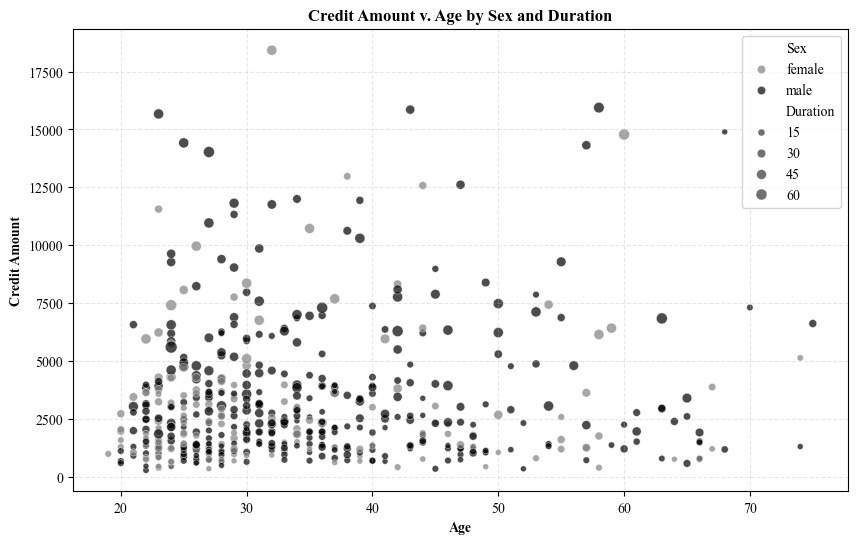

In [45]:
fig, ax = plt.subplots(figsize = (10, 6))
sns.scatterplot(data = df, x = 'Age', y = 'Credit amount', hue = 'Sex', size = 'Duration', alpha = 0.7,
                palette = {'male': 'black', 'female': 'grey'}, ax = ax)
ax.set_title('Credit Amount v. Age by Sex and Duration', fontweight = 'bold', fontsize = 12)
ax.set_xlabel('Age', fontweight = 'bold')
ax.set_ylabel('Credit Amount', fontweight = 'bold')
ax.grid(True, linestyle = '--', alpha = 0.3)

plt.show()

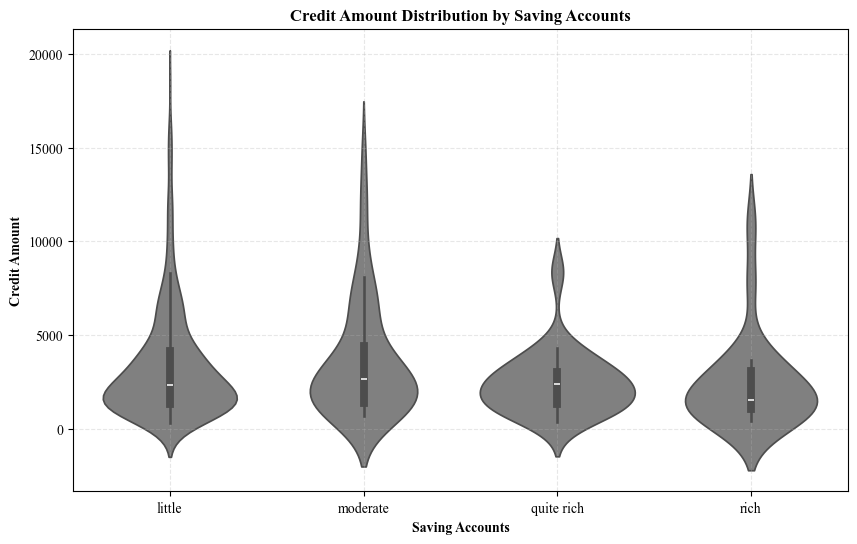

In [48]:
fig, ax = plt.subplots(figsize = (10, 6))
sns.violinplot(data = df, x = 'Saving accounts', y = 'Credit amount', color = 'grey', ax = ax)
ax.set_title('Credit Amount Distribution by Saving Accounts', fontweight = 'bold', fontsize = 12)
ax.set_xlabel('Saving Accounts', fontweight = 'bold')
ax.set_ylabel('Credit Amount', fontweight = 'bold')
ax.grid(True, linestyle = '--', alpha = 0.3)

plt.show()

In [49]:
df['Risk'].value_counts(normalize = True) * 100

Risk
good    55.747126
bad     44.252874
Name: proportion, dtype: float64

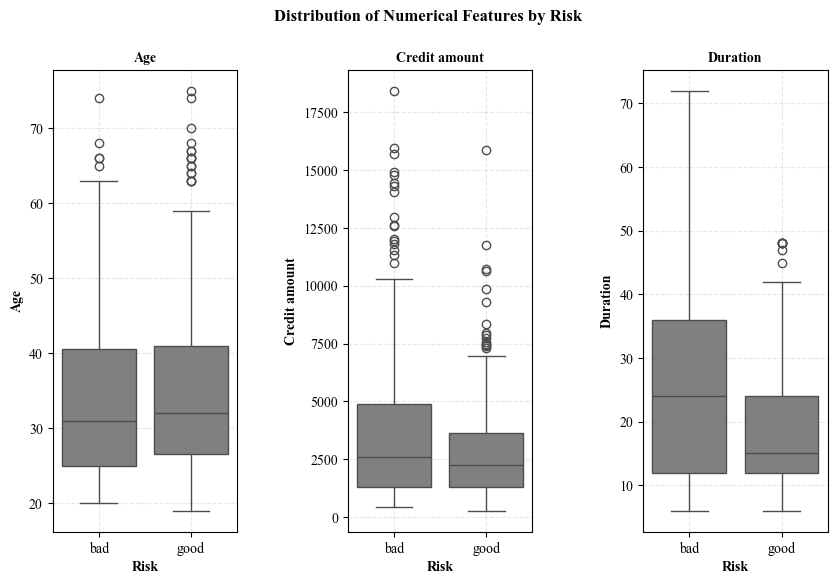

In [61]:
fig, axes = plt.subplots(1, 3, figsize = (10, 6))
fig.suptitle('Distribution of Numerical Features by Risk', fontweight = 'bold', fontsize = 12)
for ax, col in zip(axes, ['Age', 'Credit amount', 'Duration']):
    sns.boxplot(data = df, x = 'Risk', y = col, color = 'grey', ax = ax)
    ax.set_title(col, fontweight = 'bold', fontsize = 10)
    ax.set_xlabel('Risk', fontweight = 'bold')
    ax.set_ylabel(col, fontweight = 'bold')
    ax.grid(True, linestyle = '--', alpha = 0.3)

plt.subplots_adjust(top = 0.88, wspace = 0.6)
plt.show()

In [53]:
df.groupby('Risk')[['Age', 'Credit amount', 'Duration']].mean()

,Age,Credit amount,Duration
Risk,,,
bad,34.147186,3881.090909,25.445887
good,35.477663,2800.594502,18.079038


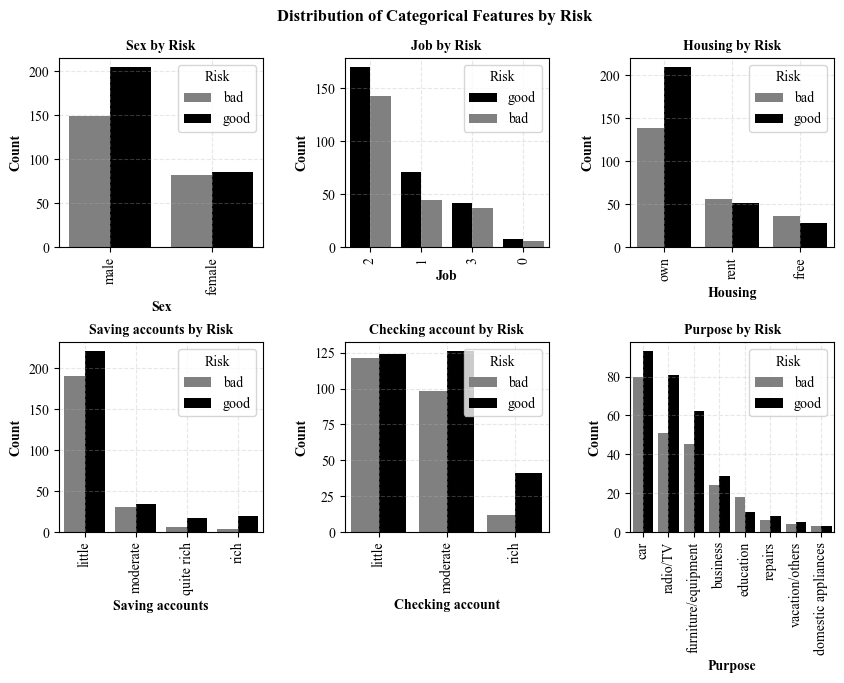

In [64]:
fig, axes = plt.subplots(2, 3, figsize = (10, 6))
fig.suptitle('Distribution of Categorical Features by Risk', fontweight = 'bold', fontsize = 12)
for ax, col in zip(axes.flatten(), categorical_cols):
    sns.countplot(data = df, x = col, hue = 'Risk', order = df[col].value_counts().index,
        palette = {'good': 'black', 'bad': 'grey'}, ax = ax)   
    ax.set_title(f'{col} by Risk', fontweight = 'bold', fontsize = 10)
    ax.set_xlabel(col, fontweight = 'bold')
    ax.set_ylabel('Count', fontweight = 'bold')
    ax.tick_params(axis = 'x', rotation = 90)
    ax.grid(True, linestyle = '--', alpha = 0.3)

plt.subplots_adjust(top = 0.90, hspace = 0.5, wspace = 0.4)
plt.show()

In [65]:
features = ['Age', 'Sex', 'Job', 'Housing', 'Saving accounts', 'Checking account', 'Credit amount']
target = 'Risk'

df_model = df[features + [target]].copy()
df_model.head()

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Risk
0,22,female,2,own,little,moderate,5951,bad
1,45,male,2,free,little,little,7882,good
2,53,male,2,free,little,little,4870,bad
3,35,male,3,rent,little,moderate,6948,good
4,28,male,3,own,little,moderate,5234,bad


In [66]:
from sklearn.preprocessing import LabelEncoder
import joblib

In [67]:
categorical_cols = df_model.select_dtypes(include = 'object').columns.drop('Risk')

In [69]:
le_dict = {}

for col in categorical_cols:
    le = LabelEncoder()
    df_model[col] = le.fit_transform(df_model[col])
    le_dict[col] = le
    joblib.dump(le, f'Credit Risk Modelling - Label Encoder ({col}).pkl')

In [71]:
le_target = LabelEncoder()
df_model[target] = le_target.fit_transform(df_model[target])
df_model[target]

0      0
1      1
2      0
3      1
4      0
      ..
517    1
518    1
519    1
520    0
521    1
Name: Risk, Length: 522, dtype: int64

In [72]:
joblib.dump(le_target, 'Credit Risk Modelling - Label Encoder (Target).pkl')

['Credit Risk Modelling - Label Encoder (Target).pkl']

In [73]:
df_model.head()

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Risk
0,22,0,2,1,0,1,5951,0
1,45,1,2,0,0,0,7882,1
2,53,1,2,0,0,0,4870,0
3,35,1,3,2,0,1,6948,1
4,28,1,3,1,0,1,5234,0


In [74]:
from sklearn.model_selection import train_test_split

In [75]:
X = df_model.drop(target, axis = 1)
y = df_model[target]

In [76]:
X

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount
0,22,0,2,1,0,1,5951
1,45,1,2,0,0,0,7882
2,53,1,2,0,0,0,4870
3,35,1,3,2,0,1,6948
4,28,1,3,1,0,1,5234
...,...,...,...,...,...,...,...
517,48,1,1,1,0,1,1743
518,30,1,3,1,0,0,3959
519,40,1,3,1,0,0,3857
520,23,1,2,0,0,0,1845


In [77]:
y

0      0
1      1
2      0
3      1
4      0
      ..
517    1
518    1
519    1
520    0
521    1
Name: Risk, Length: 522, dtype: int64

In [78]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, stratify = y, random_state = 1)

In [79]:
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(417, 7) (105, 7) (417,) (105,)


In [80]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import GridSearchCV

In [81]:
def train_model(model, param_grid, X_train, y_train, X_test, y_test):
    grid = GridSearchCV(model, param_grid, cv = 5, scoring = 'accuracy', n_jobs = -1)
    grid.fit(X_train, y_train)
    best_model = grid.best_estimator_
    y_pred = best_model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    return best_model, acc, grid.best_params_

In [82]:
dt = DecisionTreeClassifier(random_state = 1, class_weight = 'balanced', n_jobs = -1)

dt_param_grid = {'max_depth': [3, 5, 7, 10, None],
                'min_samples_split': [2, 5, 10],
                'min_samples_leaf': [1, 2, 4]}

best_dt, acc_dt, params_dt = train_model(dt, dt_param_grid, X_train, y_train, X_test, y_test)

In [83]:
print('Decision Tree Accuracy:', acc_dt)
print('Decision Tree Best Parameters:', params_dt)

Decision Tree Accuracy: 0.6857142857142857
Decision Tree Best Parameters: {'max_depth': 10, 'min_samples_leaf': 4, 'min_samples_split': 10}


In [84]:
rf = RandomForestClassifier(random_state = 1, class_weight = 'balanced', n_jobs = -1)

rf_param_grid = {'n_estimators': [100, 200],
                 'max_depth': [5, 7, 10, None],
                 'min_samples_split': [2, 5, 10],
                 'min_samples_leaf': [1, 2, 4]}

best_rf, acc_rf, params_rf = train_model(rf, rf_param_grid, X_train, y_train, X_test, y_test)

In [85]:
print('Random Forest Accuracy:', acc_rf)
print('Random Forest Best Parameters:', params_rf)

Random Forest Accuracy: 0.638095238095238
Random Forest Best Parameters: {'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 100}


In [86]:
et = ExtraTreesClassifier(random_state = 1, class_weight = 'balanced', n_jobs = -1)

et_param_grid = {'n_estimators': [100, 200],
                 'max_depth': [5, 7, 10, None],
                 'min_samples_split': [2, 5, 10],
                 'min_samples_leaf': [1, 2, 4]}

best_et, acc_et, params_et = train_model(et, et_param_grid, X_train, y_train, X_test, y_test)

In [87]:
print('Extra Trees Accuracy:', acc_et)
print('Extra Trees Best Parameters:', params_et)

Extra Trees Accuracy: 0.580952380952381
Extra Trees Best Parameters: {'max_depth': 5, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 100}


In [89]:
xgb = XGBClassifier(random_state = 1, scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum(), 
                    use_label_encoder = False, eval_metric = 'logloss')

xgb_param_grid = {'n_estimators': [100, 200],
                 'max_depth': [3, 5, 7],
                 'learning_rate': [0.01, 0.1, 0.2],
                 'subsample': [0.7, 1],
                 'colsample_bytree': [0.7, 1]}

best_xgb, acc_xgb, params_xgb = train_model(xgb, xgb_param_grid, X_train, y_train, X_test, y_test)

C:\Users\dilan\AppData\Local\Programs\Python\Python312\Lib\site-packages\xgboost\training.py:200: UserWarning: [13:29:46] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:793: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [90]:
print('XGBoost Accuracy:', acc_xgb)
print('XGBoost Best Parameters:', params_xgb)

XGBoost Accuracy: 0.6
XGBoost Best Parameters: {'colsample_bytree': 0.7, 'learning_rate': 0.01, 'max_depth': 5, 'n_estimators': 100, 'subsample': 0.7}


In [91]:
joblib.dump(best_dt, 'Credit Risk Modelling - Decision Tree Model.pkl')

['Credit Risk Modelling - Decision Tree Model.pkl']